In [2]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

In [3]:
scenario_blocks = pd.read_pickle('../data/prostor/scenario_blocks.pickle')

In [4]:
scenario_blocks

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN
...,...,...,...,...,...,...,...,...,...,...
65,"POLYGON ((390950.379 6643779.96, 390941.389 66...",0.000000,1.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,1.000000
66,"POLYGON ((391069.678 6644283.933, 391072.529 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,1.00000,LandUse.AGRICULTURE,1.000000
67,"POLYGON ((388222.552 6643218.262, 388215.418 6...",0.000000,0.000000,0.0,0.0,0.910136,0.0,0.00000,LandUse.TRANSPORT,0.910136
68,"POLYGON ((388314.421 6645193.77, 388311.871 66...",0.000000,1.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,1.000000


In [5]:
blocks = pd.read_pickle('../data/prostor/prepared_blocks.pickle')

In [6]:
blocks

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,AGRICULTURE,0.918180,6260.339339,...,0.0,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,BUSINESS,0.938081,18143.803825,...,0.0,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,TRANSPORT,0.891381,15011.639457,...,0.0,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,RESIDENTIAL,0.934862,22467.050757,...,1467.0,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,0.0,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,1890.365026,...,0.0,22875.011366,0.142502,0.082639,0.000000,1.724397,low-rise non-residential,171.630011,"POLYGON ((385491.114 6631441.4, 385461.315 663...",2695
2696,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,114.633629,...,0.0,1214.910251,0.175975,0.094356,0.000000,1.865014,low-rise non-residential,170.264769,"POLYGON ((384982.003 6631777.757, 384981.913 6...",2696
2697,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,227.599494,...,0.0,2449.592208,0.172016,0.092913,0.000000,1.851366,low-rise non-residential,170.513227,"POLYGON ((384824.685 6631717.789, 384794.391 6...",2697
2698,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.412833,...,0.0,5.073803,0.252905,0.081366,0.000000,3.108261,low-rise non-residential,170.672224,"POLYGON ((384723.149 6631740.203, 384723.035 6...",2698


In [7]:
# ==== 0. Импорты ====
import pandas as pd
import numpy as np
import geopandas as gpd
from libpysal.weights import DistanceBand, lag_spatial
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# ==== 1. Входные данные ====
# blocks = gpd.read_file("blocks.geojson")  # если нужно загрузить
# Укажи свои списки признаков:
orig_feats = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility'
]
cat_feats = ['land_use', 'morphotype']
numeric_feats = [c for c in orig_feats if c not in cat_feats]
radius_list = [300, 500, 1000, 2000, 3000]

# ==== 2. Модель ====
model = CatBoostRegressor()
model.load_model("../data/prostor/model.cbm")  # .cbm обучен на лог-цене

# ==== 3. Весовые матрицы по радиусам ====
w_radii = {}
for r in radius_list:
    w = DistanceBand.from_dataframe(
        blocks, threshold=r, binary=True, silence_warnings=True
    )
    w.transform = 'r'  # row-standardized
    w_radii[r] = w

# ==== 4. Функция лагов ====
def add_lags(frame: pd.DataFrame, numeric_feats, w_radii):
    f = frame.copy()
    gm = f[numeric_feats].mean()
    lag_cols = []
    for feat in numeric_feats:
        vec = f[feat].fillna(gm[feat])
        for r, w in w_radii.items():
            col = f'lag{r}_{feat}'
            f[col] = lag_spatial(w, vec)
            lag_cols.append(col)
    for r, w in w_radii.items():
        ncol = f'n_neighbors_{r}'
        f[ncol] = pd.Series({i: len(nb) for i, nb in w.neighbors.items()})
        lag_cols.append(ncol)
    return f, lag_cols

# ==== 5. Подготовка фичей и предсказание ====
blocks_with_lags, lag_cols = add_lags(blocks, numeric_feats, w_radii)
all_feats = orig_feats + lag_cols

X = blocks_with_lags[all_feats].copy()
for c in cat_feats:
    if c in X.columns:
        X[c] = X[c].fillna('missing').astype('category')

y_log = model.predict(X)                    # лог-цена
blocks_pred = blocks_with_lags.copy()
blocks_pred['y_log_pred'] = y_log
blocks_pred['price_pred'] = np.exp(y_log)   # цена





/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

Суммарная стоимость:
 • Сценические кварталы: 3 932 359 912 ₽
 • Контекст: 145 408 247 937 ₽
 • Все кварталы: 149 340 607 849 ₽


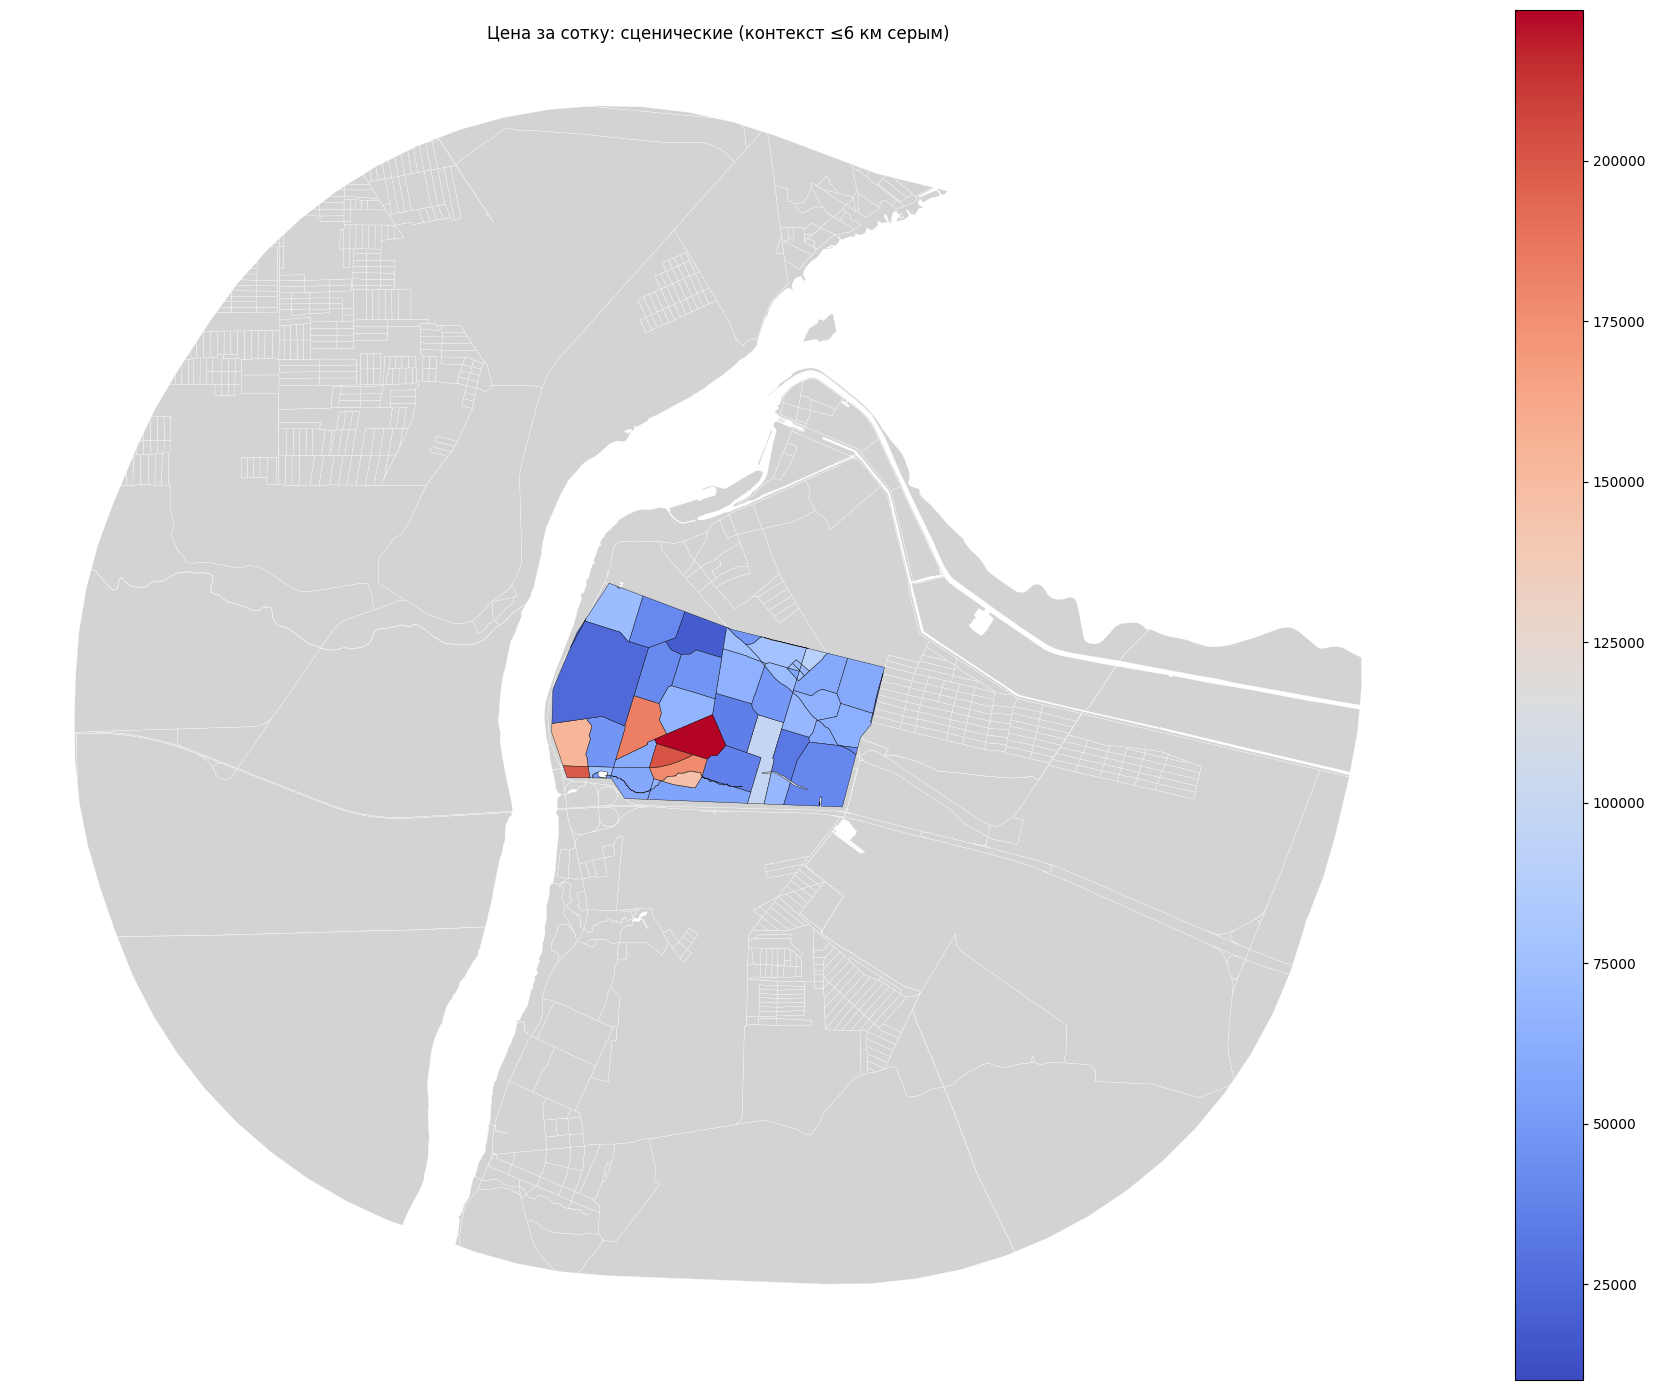

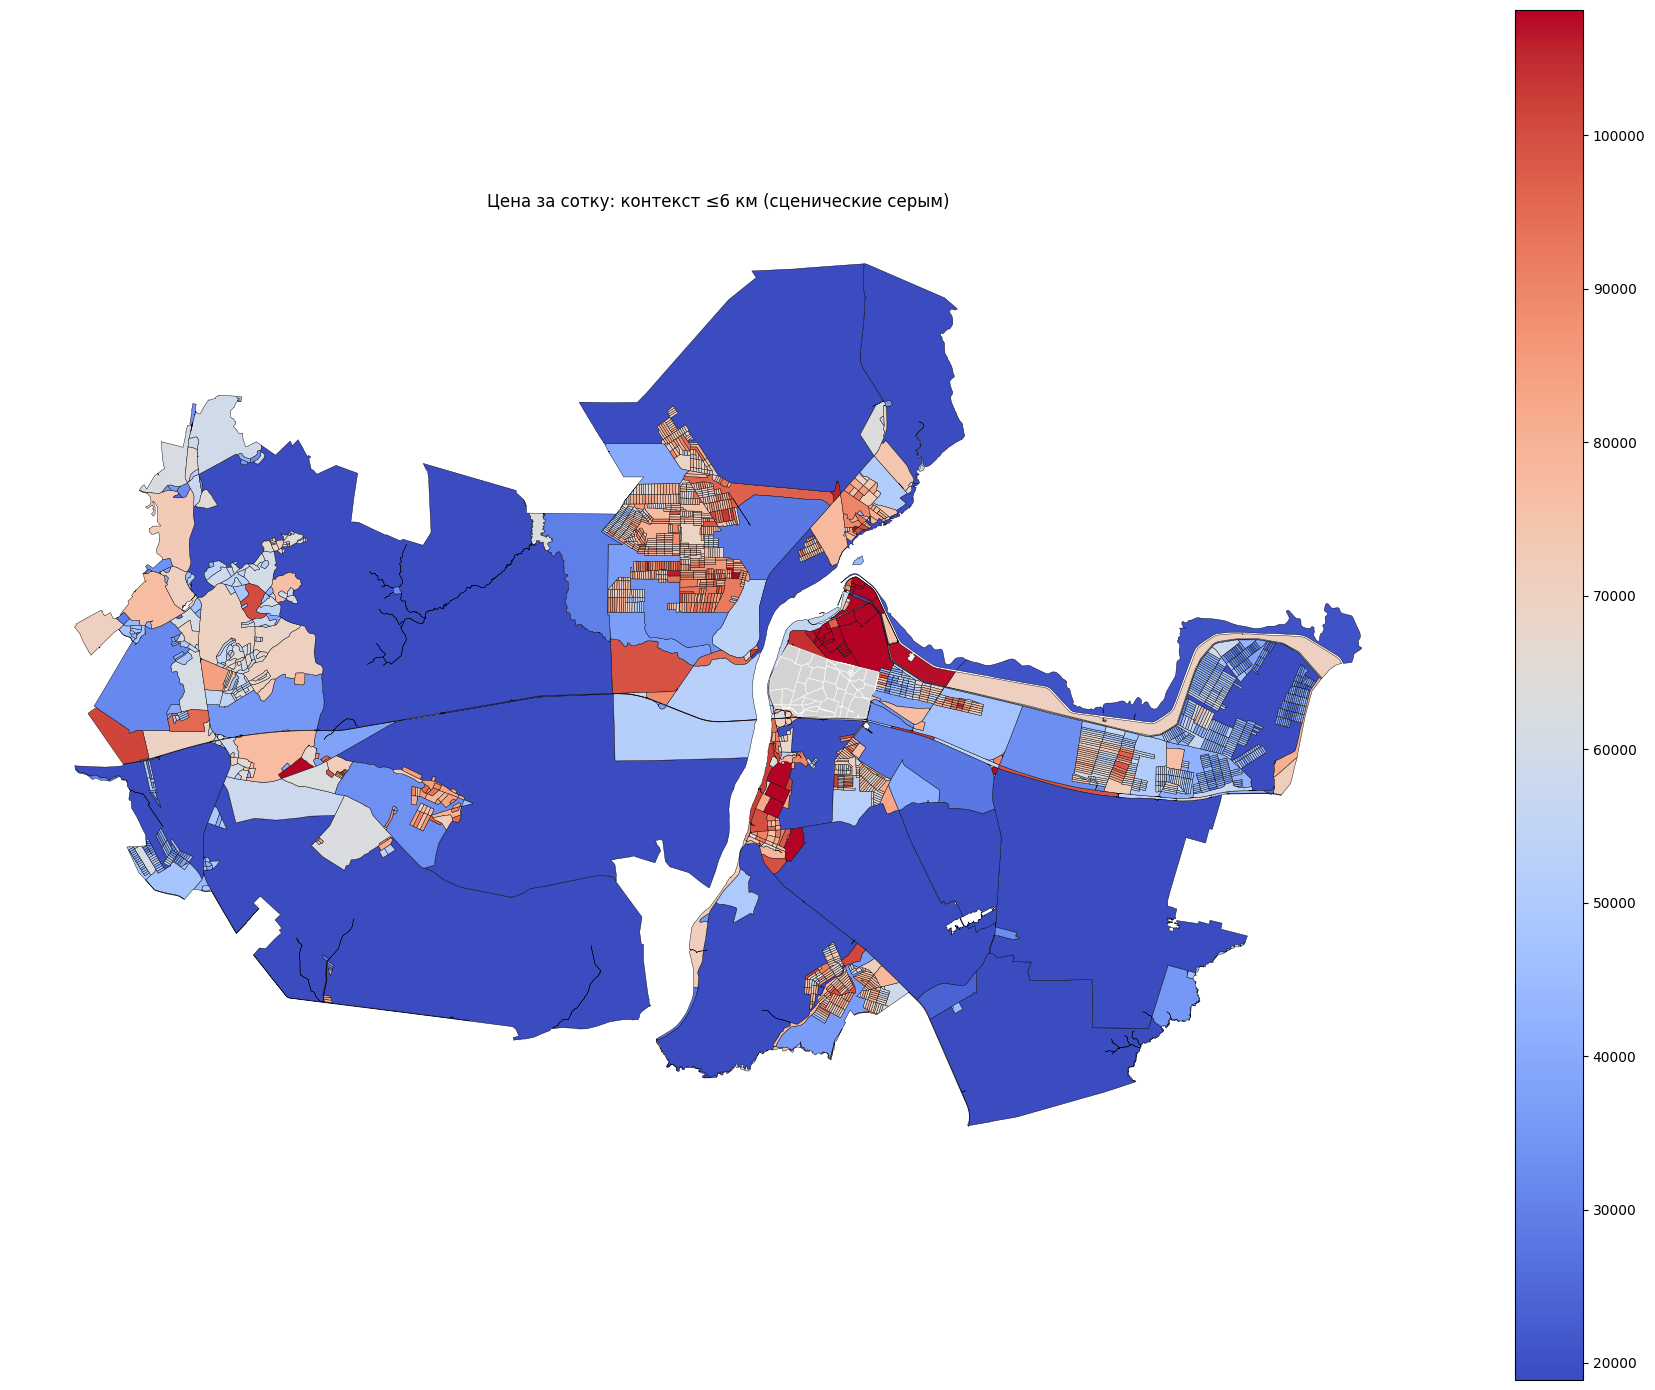

In [8]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

scenario = scenario_blocks.copy()  # сценарий 

# 0) цена и цена за сотку
if 'price_pred' not in blocks_pred.columns and 'y_log_pred' in blocks_pred.columns:
    blocks_pred['price_pred'] = np.exp(blocks_pred['y_log_pred'])
a = blocks_pred['site_area'].astype(float)
blocks_pred['price_per_sotka'] = np.where(a > 0, blocks_pred['price_pred'] / a * 100, np.nan)

# 1) CRS
if scenario.crs != blocks_pred.crs:
    scenario = scenario.to_crs(blocks_pred.crs)

# 2) флаг сценических (если нет)
if 'is_scn' not in blocks_pred.columns:
    sjoin_df = gpd.sjoin(
        blocks_pred[['geometry']].reset_index().rename(columns={'index':'_idx'}),
        scenario[['geometry']], how='inner', predicate='intersects'
    )
    scn_idx = sjoin_df['_idx'].unique()
    blocks_pred['is_scn'] = blocks_pred.index.isin(scn_idx)

scn = blocks_pred[blocks_pred['is_scn']].copy()
ctx = blocks_pred[~blocks_pred['is_scn']].copy()

# 3) буфер 6 км и отдельный gdf контекста
def make_buffer_m(gdf, radius_m):
    g = gpd.GeoDataFrame(geometry=[gdf.geometry.union_all()], crs=gdf.crs)
    if g.crs and g.crs.is_geographic:
        utm = g.estimate_utm_crs()
        g = g.to_crs(utm); g['geometry'] = g.buffer(radius_m); g = g.to_crs(blocks_pred.crs)
    else:
        g['geometry'] = g.buffer(radius_m)
    return g

buf6_gdf = make_buffer_m(scenario, 5000)
context_6km = gpd.clip(ctx, buf6_gdf)               # контекст, обрезанный буфером
# при желании оставить только попадающие целиком:
# context_6km = ctx[ctx.intersects(buf6_gdf.geometry.iloc[0])].copy()

# 4) статистика по ВСЕМ
total_scn = float(scn['price_pred'].sum())
total_ctx_all = float(ctx['price_pred'].sum())
total_all = float(blocks_pred['price_pred'].sum())

print("Суммарная стоимость:")
print(" • Сценические кварталы:", f"{total_scn:,.0f} ₽".replace(',', ' '))
print(" • Контекст:",             f"{total_ctx_all:,.0f} ₽".replace(',', ' '))
print(" • Все кварталы:",         f"{total_all:,.0f} ₽".replace(',', ' '))



# 5) карта: сценические (контекст = context_6km серым)
vmin1 = scn['price_per_sotka'].quantile(0.02) if len(scn) else blocks_pred['price_per_sotka'].min()
vmax1 = scn['price_per_sotka'].quantile(0.98) if len(scn) else blocks_pred['price_per_sotka'].max()
fig, ax = plt.subplots(figsize=(18, 14))
context_6km.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2, zorder=1)
scn.plot(ax=ax, column='price_per_sotka', cmap='coolwarm',
         vmin=vmin1, vmax=vmax1, legend=True,
         edgecolor='black', linewidth=0.3, zorder=2)
ax.set_title('Цена за сотку: сценические (контекст ≤6 км серым)'); ax.axis('off')
plt.tight_layout(); plt.show()

# 6) карта: контекст ≤6 км по цене за сотку, сценические серым
vmin2 = blocks_pred['price_per_sotka'].quantile(0.02) if len(blocks_pred) else blocks_pred['price_per_sotka'].min()
vmax2 = blocks_pred['price_per_sotka'].quantile(0.98) if len(blocks_pred) else blocks_pred['price_per_sotka'].max()

fig, ax = plt.subplots(figsize=(18, 14))
# контекст окрашиваем
if len(blocks_pred):
    blocks_pred.plot(
        ax=ax, column='price_per_sotka', cmap='coolwarm',
        vmin=vmin2, vmax=vmax2, legend=True,
        edgecolor='black', linewidth=0.3, zorder=1
    )
# сценические серым сверху
if len(scn):
    scn.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5, zorder=2)

ax.set_title('Цена за сотку: контекст ≤6 км (сценические серым)', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()



/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

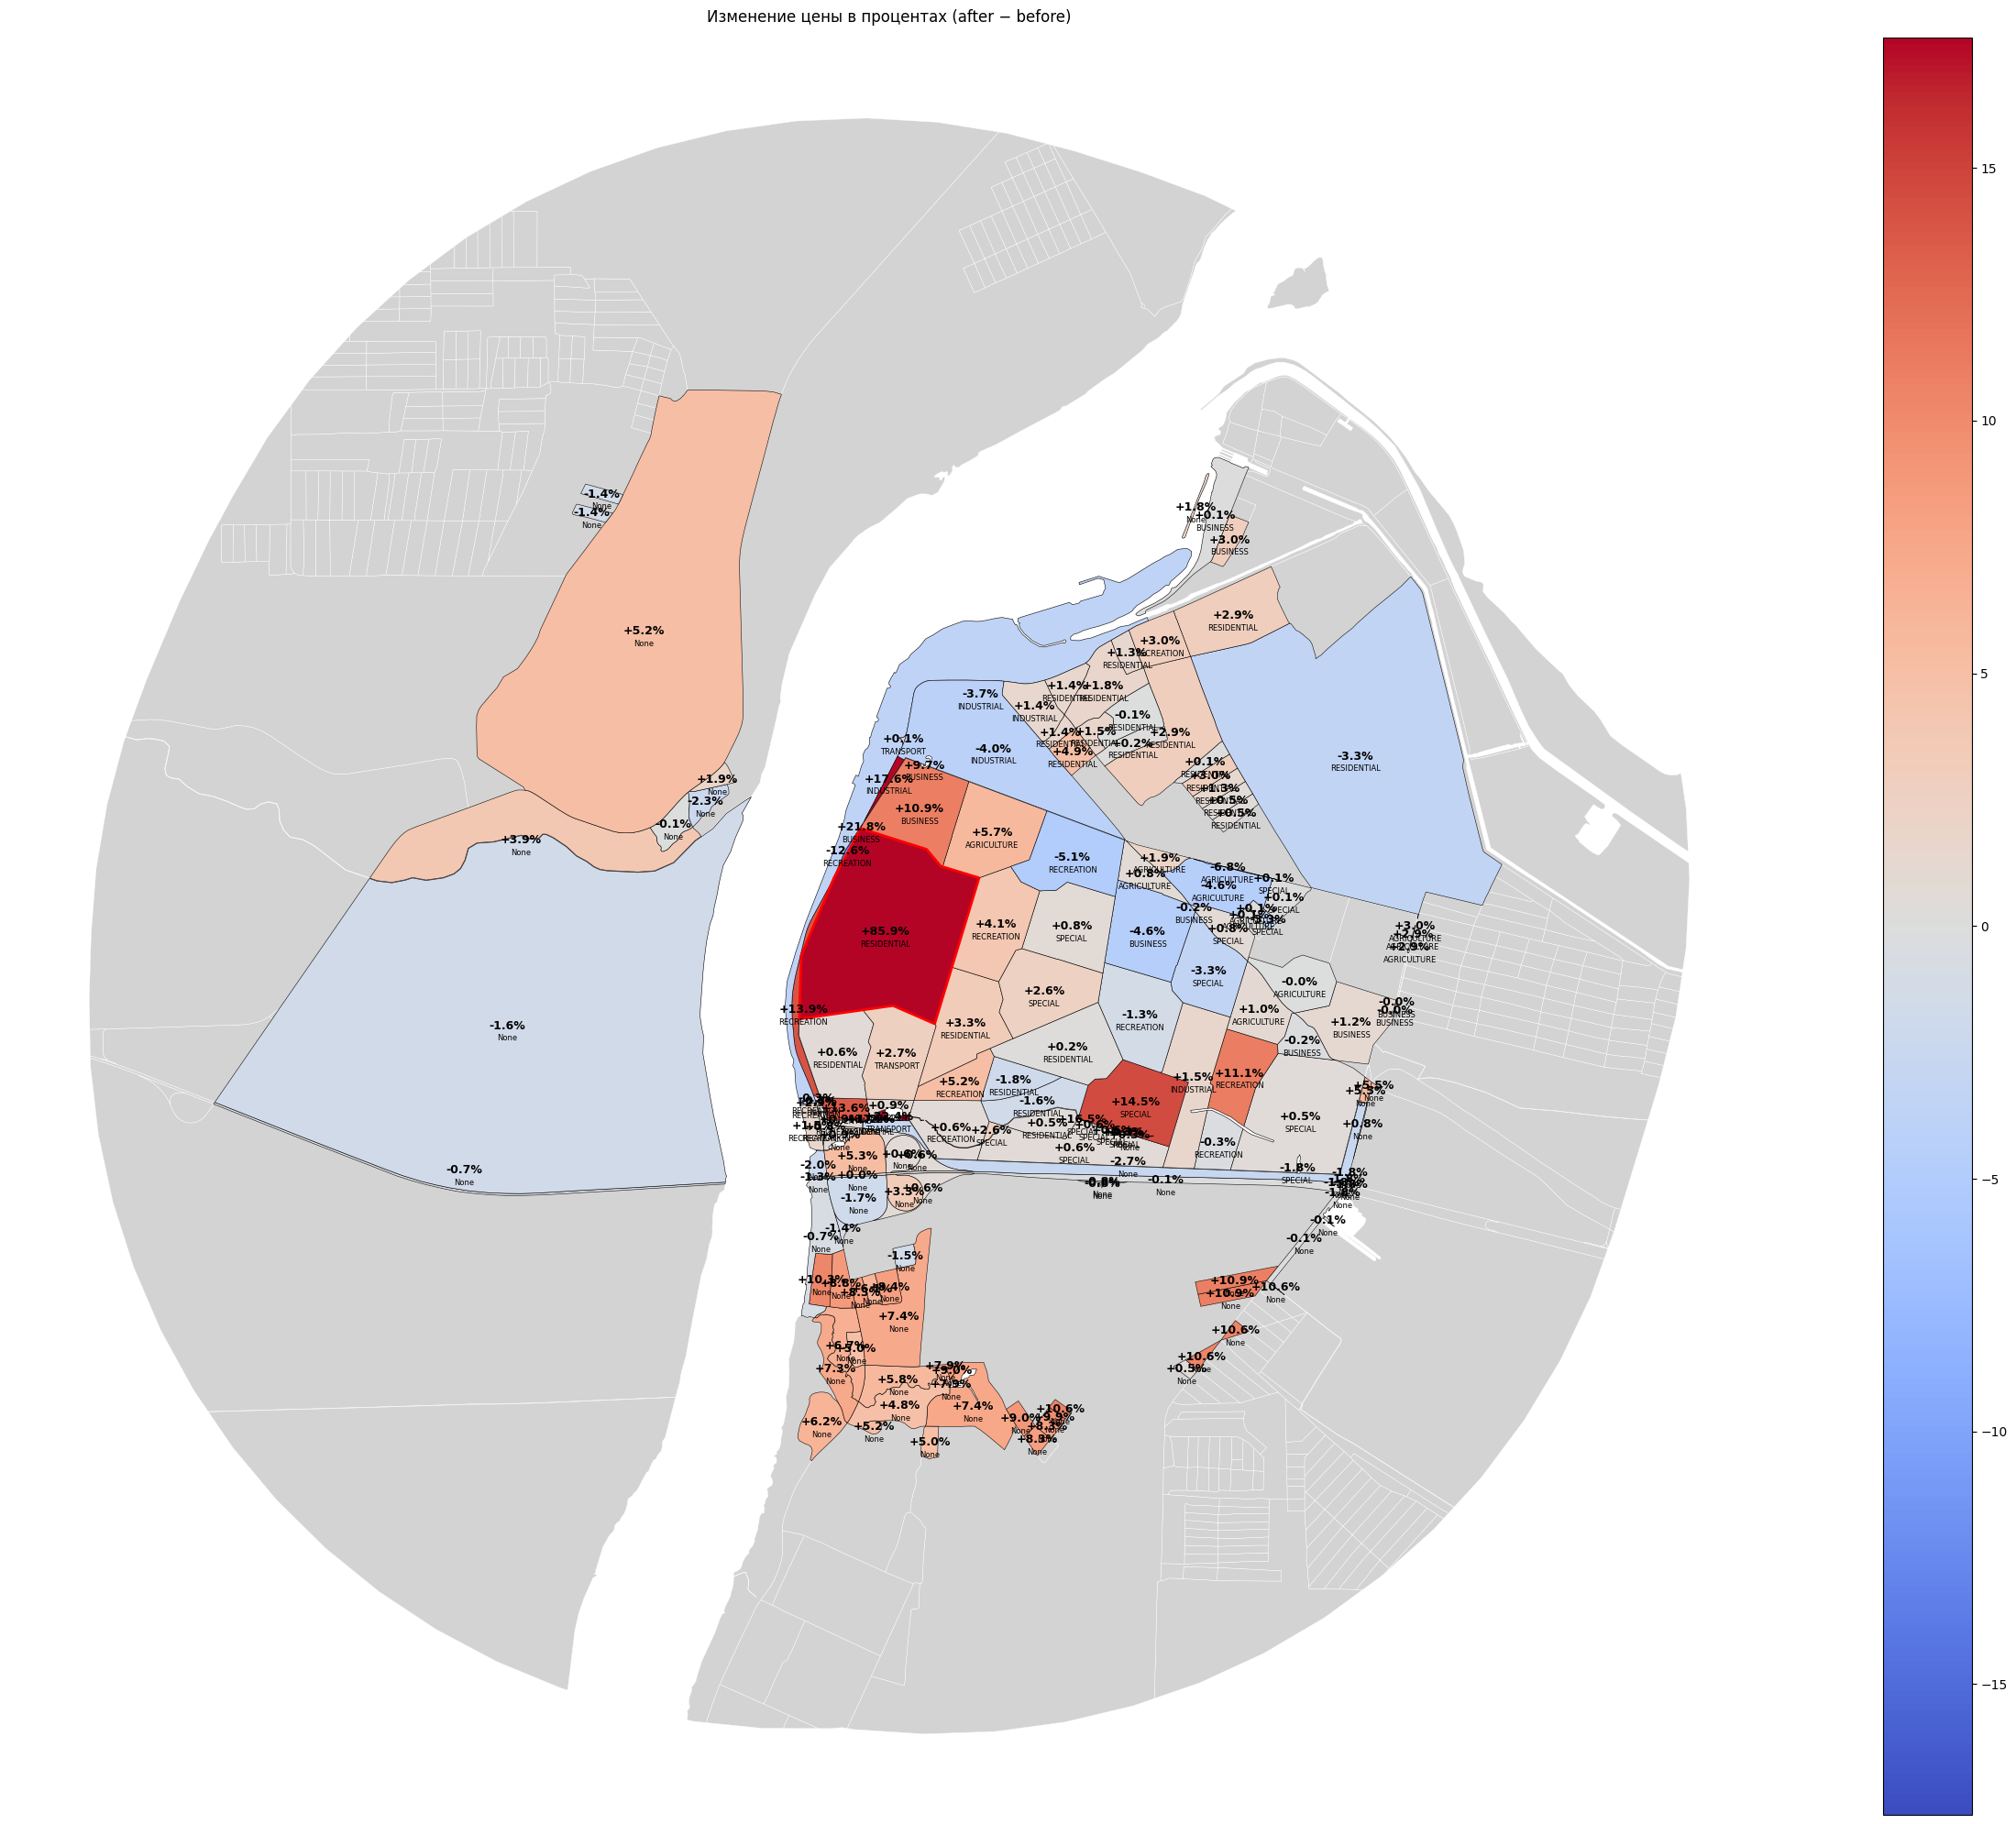


Статистика по кварталам в пределах 5 км:
index | до (₽) → после (₽) | Δ₽ | Δ%
1031 | 642 316 714 ₽ → 642 316 714 ₽ | +0 ₽ | +0.0%
1047 | 15 661 565 ₽ → 15 661 565 ₽ | +0 ₽ | +0.0%
1038 | 19 553 122 ₽ → 19 553 122 ₽ | +0 ₽ | +0.0%
1045 | 11 369 337 ₽ → 11 369 337 ₽ | +0 ₽ | +0.0%
1039 | 18 054 656 ₽ → 18 054 656 ₽ | +0 ₽ | +0.0%
1046 | 11 835 306 ₽ → 11 835 306 ₽ | +0 ₽ | +0.0%
1033 | 15 886 352 ₽ → 15 886 352 ₽ | +0 ₽ | +0.0%
1583 | 10 970 600 ₽ → 10 970 600 ₽ | +0 ₽ | +0.0%
1540 | 12 095 849 ₽ → 12 095 849 ₽ | +0 ₽ | +0.0%
1041 | 5 461 862 ₽ → 5 461 862 ₽ | +0 ₽ | +0.0%
1452 | 8 985 719 ₽ → 8 985 719 ₽ | +0 ₽ | +0.0%
120 | 11 608 226 ₽ → 11 608 226 ₽ | +0 ₽ | +0.0%
123 | 14 973 877 ₽ → 14 973 877 ₽ | +0 ₽ | +0.0%
1032 | 11 183 648 ₽ → 11 183 648 ₽ | +0 ₽ | +0.0%
1054 | 11 408 454 ₽ → 11 408 454 ₽ | +0 ₽ | +0.0%
1044 | 5 099 148 ₽ → 5 099 148 ₽ | +0 ₽ | +0.0%
1043 | 5 464 600 ₽ → 5 464 600 ₽ | +0 ₽ | +0.0%
1582 | 5 761 377 ₽ → 5 761 377 ₽ | +0 ₽ | +0.0%
1539 | 5 514 949 ₽ → 5 514 949 

In [9]:
# ------------ 0. Импорты и константы ------------
import pandas as pd
import numpy as np
import geopandas as gpd
from catboost import CatBoostRegressor
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy

orig_feats = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility'
]
cat_feats = ['land_use', 'morphotype']
numeric_feats = [c for c in orig_feats if c not in cat_feats]
radius_list = [300, 500, 1000, 2000, 3000]

# ------------ 1. Данные и модель ------------
# blocks: GeoDataFrame с исходными фичами и geometry
model = CatBoostRegressor()
model.load_model('../data/prostor/model.cbm')

# ------------ 2. Матрицы соседства ------------
w_radii = {}
for r in radius_list:
    w = DistanceBand.from_dataframe(blocks, threshold=r, binary=True, silence_warnings=True)
    w.transform = 'r'
    w_radii[r] = w

# ------------ 3. Применение сценария к одному кварталу ------------
def apply_scenario(blocks, target_idx: int, changes: dict) -> pd.DataFrame:
    df = blocks.copy()
    row = df.loc[target_idx].to_dict()
    row.update(changes)

    site_area = float(row['site_area'])

    build = float(row.get('build_floor_area', df.at[target_idx, 'build_floor_area']))
    live  = float(row.get('living_area',       df.at[target_idx, 'living_area']))
    non   = row.get('non_living_area', np.nan)

    if not np.isfinite(non):
        if 'build_floor_area' in changes and 'living_area' in changes:
            non = max(build - live, 0.0)
        elif ('mxi' in changes) or ('mxi' in row):
            mxi = float(row.get('mxi', df.at[target_idx, 'mxi']))
            non = max(mxi * build, 0.0)
        else:
            non = float(df.at[target_idx, 'non_living_area'])

    if ('non_living_area' in changes and 'living_area' in changes) and ('build_floor_area' not in changes):
        build = live + non

    row['build_floor_area'] = build
    row['living_area']      = live
    row['non_living_area']  = non

    footprint = float(row.get('footprint_area', df.at[target_idx, 'footprint_area']))
    pop       = float(row.get('population',     df.at[target_idx, 'population']))

    row['fsi']  = build / site_area if site_area > 0 else np.nan
    row['gsi']  = footprint / site_area if site_area > 0 else np.nan
    row['mxi']  = (non / build) if build > 0 else 0.0
    row['l']    = (build / pop) if pop > 0 else np.nan
    row['osr']  = (site_area - footprint) / site_area if site_area > 0 else np.nan
    row['share_living']     = live / site_area if site_area > 0 else np.nan
    row['share_non_living'] = non / site_area if site_area > 0 else np.nan

    if 'residential' in changes and 'share' not in changes:
        row['share'] = float(row['residential'])

    for k, v in row.items():
        df.at[target_idx, k] = v

    return df

# ------------ 4. Визуализация «до/после» в радиусе 5 км ------------
def plot_scenario_with_radii_from_blocks(
    blocks_before, blocks_after, w_radii, model,
    orig_feats, numeric_feats, target_idx, eps=1e-9
):
    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # — форматтеры —
    def fmt_rub(x, signed=False, digits=0):
        try:
            x = float(x)
            if not np.isfinite(x): return '—'
            s = f"{x:+,.{digits}f}" if signed else f"{x:,.{digits}f}"
            return s.replace(',', ' ') + " ₽"
        except Exception:
            return '—'

    def fmt_pct(x, digits=1):
        try:
            x = float(x)
            if not np.isfinite(x): return '—'
            return f"{x:+.{digits}f}%"
        except Exception:
            return '—'

    # — лаги по всему фрейму —
    radius_list = sorted(w_radii.keys())
    def add_lags(frame):
        f = frame.copy()
        gm = f[numeric_feats].mean()
        lag_cols = []
        for feat in numeric_feats:
            vec = f[feat].fillna(gm[feat])
            for r in radius_list:
                col = f'lag{r}_{feat}'
                f[col] = lag_spatial(w_radii[r], vec)
                lag_cols.append(col)
        for r in radius_list:
            ncol = f'n_neighbors_{r}'
            f[ncol] = pd.Series({i: len(nb) for i, nb in w_radii[r].neighbors.items()})
            lag_cols.append(ncol)
        return f, lag_cols

    b_with_lags, lag_cols = add_lags(blocks_before)
    a_with_lags, _        = add_lags(blocks_after)

    all_feats = orig_feats + lag_cols
    Xb = b_with_lags[all_feats].copy()
    Xa = a_with_lags[all_feats].copy()
    for X in (Xb, Xa):
        if 'land_use' in X:   X['land_use']   = X['land_use'].fillna('missing').astype('category')
        if 'morphotype' in X: X['morphotype'] = X['morphotype'].fillna('missing').astype('category')

    # — предсказания лог-цен и цены —
    log_before = model.predict(Xb)
    log_after  = model.predict(Xa)

    gdf_all = a_with_lags.copy()
    gdf_all['price_before'] = np.exp(log_before)
    gdf_all['price_after']  = np.exp(log_after)
    gdf_all['d_rub'] = gdf_all['price_after'] - gdf_all['price_before']
    gdf_all['d_pct'] = (gdf_all['price_after'] / gdf_all['price_before'] - 1.0) * 100

    # — буфер 5 км от целевого квартала —
    tgt_geom = blocks_before.loc[target_idx, 'geometry']
    buf = gpd.GeoSeries([tgt_geom], crs=blocks_before.crs)
    if buf.crs and buf.crs.is_geographic:
        utm = buf.estimate_utm_crs()
        buf = buf.to_crs(utm).buffer(4000).to_crs(blocks_before.crs)
    else:
        buf = buf.buffer(4000)
    buf_poly = gpd.GeoDataFrame(geometry=buf, crs=blocks_before.crs)

    gdf_map = gpd.clip(gdf_all, buf_poly)

    # — слои для карты —
    changed   = gdf_map[np.abs(gdf_map['d_rub'].astype(float)) > eps].copy()
    unchanged = gdf_map[np.abs(gdf_map['d_rub'].astype(float)) <= eps].copy()

    # — шкала —
    if len(changed):
        ql, qh = changed['d_pct'].quantile([0.02, 0.98]).astype(float)
        lim = float(max(abs(ql), abs(qh)))
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = -1.0, 1.0

    # — карта —
    # --- карта: внутри 5 км; неизменные серым, изменённые по % ---
    fig, ax = plt.subplots(figsize=(25, 20))
    if len(unchanged):
        unchanged.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=1)
    if len(changed):
        changed.plot(ax=ax, column='d_pct', cmap='coolwarm',
                    vmin=vmin, vmax=vmax, legend=True,
                    edgecolor='black', linewidth=0.4, zorder=2)

    # рамка целевого
    gpd.GeoDataFrame(geometry=[blocks_before.loc[target_idx, 'geometry']], crs=blocks_before.crs) \
    .boundary.plot(ax=ax, edgecolor='red', linewidth=2.0, zorder=3)

    # # --- подписи: land_use и Δ% только для изменившихся кварталов ---
    # подписи: Δ% жирным + land_use строчкой ниже
    for _, row in changed.iterrows():
        x, y = row.geometry.centroid.coords[0]
        ax.text(x, y, f"{row['d_pct']:+.1f}%",
                ha='center', va='center', fontsize=9,
                fontweight='bold', color='black', zorder=4)
        ax.text(x, y, str(row.get('land_use', 'missing')),
                ha='center', va='center', fontsize=6, color='black',
                transform=offset_copy(ax.transData, fig=fig, y=-10, units='points'),
                zorder=4)

    ax.set_title('Изменение цены в процентах (after − before)', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # — СТАТИСТИКА ПОСЛЕ КАРТЫ —
    # строка на территорию
    print("\nСтатистика по кварталам в пределах 5 км:")
    print("index | до (₽) → после (₽) | Δ₽ | Δ%")
    for i, row in gdf_map.iterrows():
        print(
            f"{i} | {fmt_rub(row['price_before'])} → {fmt_rub(row['price_after'])} | "
            f"{fmt_rub(row['d_rub'], signed=True)} | {fmt_pct(row['d_pct'])}"
        )

    # сводка
    sum_before = float(gdf_map['price_before'].sum())
    sum_after  = float(gdf_map['price_after'].sum())
    sum_d      = sum_after - sum_before
    sum_pct    = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

    print("\nСводка по буферу 4 км:")
    print(" • Сумма до:   ", fmt_rub(sum_before))
    print(" • Сумма после:", fmt_rub(sum_after))
    print(" • Изм., ₽:    ", fmt_rub(sum_d, signed=True))
    print(" • Изм., %:    ", fmt_pct(sum_pct))
    print(" • Территорий: ", len(gdf_map))


# ------------ 5. Вызов ------------
blocks_before = blocks
changes = {
    'land_use': 'RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62
blocks_after = apply_scenario(blocks_before, target_idx, changes)

plot_scenario_with_radii_from_blocks(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    w_radii=w_radii,
    model=model,
    orig_feats=orig_feats,
    numeric_feats=numeric_feats,
    target_idx=target_idx
)
